In [1]:
import os
import yaml
import json
import argparse
from diambra.arena import load_settings_flat_dict, SpaceTypes
from diambra.arena.stable_baselines3.make_sb3_env import EnvironmentSettings, WrappersSettings
from diambra.arena.env_settings import Roles
from make_sb3_env import make_sb3_env
from diambra.arena.stable_baselines3.sb3_utils import linear_schedule, AutoSave
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import CallbackList
from wandb.integration.sb3 import WandbCallback
import wandb
from entropy_decay import EntropyDecayCallback
from adaptive_kl_lr import AdaptiveKLLRCallback
# diambra run -s 8 python stable_baselines3/training.py --cfgFile $PWD/stable_baselines3/cfg_files/sfiii3n/sr6_128x4_das_nc.yaml
import datetime

def main(cfg_file):
    # Read the cfg file
    yaml_file = open(cfg_file)
    params = yaml.load(yaml_file, Loader=yaml.FullLoader)
    print("Config parameters = ", json.dumps(params, sort_keys=True, indent=4))
    yaml_file.close()
    port = os.environ["BASE_PORT"]
    if not port.isnumeric():
        raise Exception("ERROR: BASE_PORT environment variable must be set to a number.")
    base_port = int(port)
    os.environ["DIAMBRA_ENVS"] = " ".join([f"localhost:{base_port + i}" for i in range(params["num_envs"])])

    # Settings
    params["settings"]["action_space"] = SpaceTypes.DISCRETE if params["settings"]["action_space"] == "discrete" else SpaceTypes.MULTI_DISCRETE
    settings = load_settings_flat_dict(EnvironmentSettings, params["settings"])

    # Wrappers Settings
    wrappers_settings = load_settings_flat_dict(WrappersSettings, params["wrappers_settings"])
    settings.render_mode = "human"
    settings.role = 2
    # Create environment
    env, num_envs = make_sb3_env(settings.game_id, settings, wrappers_settings,use_subprocess=True)
    print("Activated {} environment(s)".format(num_envs))

    # Policy param
    policy_kwargs = params["policy_kwargs"]

    # PPO settings
    ppo_settings = params["ppo_settings"]
    gamma = ppo_settings["gamma"]
    model_checkpoint = ppo_settings["model_checkpoint"]

    learning_rate = linear_schedule(ppo_settings["learning_rate"][0], ppo_settings["learning_rate"][1])
    clip_range = linear_schedule(ppo_settings["clip_range"][0], ppo_settings["clip_range"][1])
    clip_range_vf = clip_range
    batch_size = ppo_settings["batch_size"]
    n_epochs = ppo_settings["n_epochs"]
    n_steps = ppo_settings["n_steps"]
    ent_coef = ppo_settings["ent_coef"]
    if "target_kl" in ppo_settings:
        target_kl = ppo_settings["target_kl"]
    else:
        target_kl = None

    import random
    # Returns an integer (seconds) - generally preferred for storage
    random_seed = random.randint(0, 999999)

    base_time_path = datetime.datetime.now().strftime("%I:%M%p-on-%B-%d-%Y") + "_" + str(random_seed) + "_" + os.path.split(cfg_file)[-1]

    # init wandb as soon as possible


    tensor_board_folder = os.path.join(params["folders"]["parent_dir"], base_time_path, params["settings"]["game_id"],
                                    params["folders"]["model_name"], "tb")
    
    if model_checkpoint == "0":
        # use time to distinguish different runs
        model_folder = os.path.join(params["folders"]["parent_dir"], base_time_path, params["settings"]["game_id"], params["folders"]["model_name"], "model")
        os.makedirs(model_folder, exist_ok=False)
        # Initialize the agent
        agent = PPO("MultiInputPolicy", env, verbose=1, ent_coef=ent_coef,
                    gamma=gamma, batch_size=batch_size, target_kl=target_kl,
                    n_epochs=n_epochs, n_steps=n_steps,
                    learning_rate=learning_rate, clip_range=clip_range,
                    clip_range_vf=clip_range_vf, policy_kwargs=policy_kwargs,
                    tensorboard_log=tensor_board_folder)
    else:
        # Load the trained agent
        agent = PPO.load(model_checkpoint, env=env, ent_coef=ent_coef, target_kl=target_kl,
                         gamma=gamma, learning_rate=learning_rate, clip_range=clip_range,
                         clip_range_vf=clip_range_vf, policy_kwargs=policy_kwargs,
                         tensorboard_log=tensor_board_folder)


    # Print policy network architecture
    print("Policy architecture:")
    print(agent.policy)

    # Create the callback: autosave every USER DEF steps
    autosave_freq = ppo_settings["autosave_freq"]
    auto_save_callback = AutoSave(check_freq=autosave_freq, num_envs=num_envs,
                                  save_path=model_folder, filename_prefix=model_checkpoint + "_")

    # Train the agent
    time_steps = ppo_settings["time_steps"]

    # wandb_callback = WandbCallback(
    #     gradient_save_freq=100_000,
    #     verbose=2,
    # )
    callbacks = [ auto_save_callback]

    # Set up entropy coefficient decay if needed
    def is_number(obj):
        return isinstance(obj, (int, float, complex))

    if not is_number(ent_coef):
        ent_callback = EntropyDecayCallback(total_timesteps=time_steps, initial_ent_coef=ent_coef[0], final_ent_coef=ent_coef[1])
        callbacks.append(ent_callback)
    else:
        print("Ent coeff is a number, no decay")

    if target_kl is not None:
        adaptive_kl_lr_callback = AdaptiveKLLRCallback(
            target_kl=float(target_kl),
            lr_floor=float(ppo_settings.get("adaptive_lr_floor", 1e-5)),
            lr_cap_early=float(ppo_settings.get("adaptive_lr_cap_early", 1e-2)),
            lr_cap_late=float(ppo_settings.get("adaptive_lr_cap_late", 8e-4)),
            timestep_threshold=int(ppo_settings.get("adaptive_lr_timestep_threshold", 2_000_000)),
            early_stop_decay=float(ppo_settings.get("adaptive_lr_early_stop_decay", 1.2)),
            verbose=1,
        )
        callbacks.append(adaptive_kl_lr_callback)
        print(f"AdaptiveKLLRCallback enabled with target_kl={target_kl}")

    callback_list = CallbackList(callbacks)
    return agent, env

import os
os.environ["BASE_PORT"] = "5000"  # Set the base port for Diambra environments
agent, env = main("config/config_6_test.yaml")

/home/chenningcong/.conda/envs/my_python_env/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
2026-03-13 01:23:35.969510: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-13 01:23:36.007146: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Config parameters =  {
    "folders": {
        "model_name": "sr6_128x4_das_nc",
        "parent_dir": "./results/"
    },
    "num_envs": 2,
    "policy_kwargs": {
        "net_arch": [
            64,
            64
        ]
    },
    "ppo_settings": {
        "adaptive_lr_cap_early": 0.00025,
        "autosave_freq": 10,
        "batch_size": 256,
        "clip_range": [
            0.15,
            0.025
        ],
        "ent_coef": 0.0001,
        "gamma": 1,
        "learning_rate": [
            0.00025,
            2.5e-06
        ],
        "model_checkpoint": "0",
        "n_epochs": 4,
        "n_steps": 128,
        "target_kl": 0.01,
        "time_steps": 200000000
    },
    "settings": {
        "action_space": 2,
        "characters": "Ryu",
        "continue_game": 0.0,
        "difficulty": 8,
        "frame_shape": [
            128,
            128,
            1
        ],
        "game_id": "sfiii3n",
        "outfits": 2,
        "role": 2,
        "step_ra

/home/chenningcong/.conda/envs/my_python_env/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/chenningcong/.conda/envs/my_python_env/lib/python3.11/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Process ((), {}): Attempting to acquire lock...
Process ((), {}): ✅ Lock ACQUIRED. Executing serial task.
Process ((), {}): Attempting to acquire lock...


INFO:diambra.arena.engine.interface:Trying to connect to DIAMBRA Engine server (timeout=600s)...
INFO:diambra.arena.engine.interface:... done.
INFO:diambra.arena.arena_gym:EnvironmentSettings(game_id='sfiii3n', frame_shape=(128, 128, 1), step_ratio=6, disable_keyboard=True, disable_joystick=True, render_mode='rgb_array', splash_screen=True, rank=0, env_address='localhost:5000', grpc_timeout=600, seed=1773379419, difficulty=8, continue_game=0.0, show_final=False, tower=3, _last_seed=1773379419, pb_model=game_id: "sfiii3n"
frame_shape {
  h: 128
  w: 128
  c: 1
}
step_ratio: 6
n_players: 1
disable_keyboard: true
disable_joystick: true
action_spaces: MULTI_DISCRETE
episode_settings {
}
, n_players=1, action_space=2, role=2, characters='Ryu', outfits=2, super_art=None, fighting_style=None, ultimate_style=None, speed_mode=None)
INFO:diambra.arena.engine.interface:Trying to connect to DIAMBRA Engine server (timeout=600s)...
INFO:diambra.arena.engine.interface:... done.


Process ((), {}): Serial task COMPLETE. Releasing lock.
Process ((), {}): Lock RELEASED. Continuing execution.
Process ((), {}): Finished execution.
Process ((), {}): ✅ Lock ACQUIRED. Executing serial task.


INFO:diambra.arena.arena_gym:EnvironmentSettings(game_id='sfiii3n', frame_shape=(128, 128, 1), step_ratio=6, disable_keyboard=True, disable_joystick=True, render_mode='rgb_array', splash_screen=True, rank=1, env_address='localhost:5001', grpc_timeout=600, seed=1773379419, difficulty=8, continue_game=0.0, show_final=False, tower=3, _last_seed=1773379419, pb_model=game_id: "sfiii3n"
frame_shape {
  h: 128
  w: 128
  c: 1
}
step_ratio: 6
n_players: 1
disable_keyboard: true
disable_joystick: true
rank: 1
action_spaces: MULTI_DISCRETE
episode_settings {
}
, n_players=1, action_space=2, role=2, characters='Ryu', outfits=2, super_art=None, fighting_style=None, ultimate_style=None, speed_mode=None)


Process ((), {}): Serial task COMPLETE. Releasing lock.
Process ((), {}): Lock RELEASED. Continuing execution.
Process ((), {}): Finished execution.
Activated 2 environment(s)
Using cuda device
Wrapping the env in a VecTransposeImage.
Policy architecture:
MultiInputActorCriticPolicy(
  (features_extractor): CombinedExtractor(
    (extractors): ModuleDict(
      (action): Flatten(start_dim=1, end_dim=-1)
      (frame): NatureCNN(
        (cnn): Sequential(
          (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
          (1): ReLU()
          (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
          (3): ReLU()
          (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
          (5): ReLU()
          (6): Flatten(start_dim=1, end_dim=-1)
        )
        (linear): Sequential(
          (0): Linear(in_features=9216, out_features=256, bias=True)
          (1): ReLU()
        )
      )
      (opp_character): Flatten(start_dim=1, end_dim=-1)
      (opp_health): Flatten

In [6]:
agent.save("final_model.zip")

In [ ]:
# create an environment wrapper that injects the current stage and round to the info
# env is of type stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv
# So we create a wrapper around the DummyVecEnv that modifies the info returned by step() to include the current stage and round
from diambra.arena.wrappers.arena_wrappers import gym
class InfoWrapper(gym.Wrapper):
    def __init__(self, env):
        super(InfoWrapper, self).__init__(env)
        self.stage = 0
        self.round = 0

    def step(self, action):
        *args, info = self.env.step(action)
        if info["stage_done"]:
            self.stage += 1
        if info["round_done"]:
            self.round += 1
        info["round"] = self.round
        info["stage"] = self.stage
        return *args, info

    def reset(self, **kwargs):
        self.stage = 0
        self.round = 0
        observation = self.env.reset(**kwargs)
        return observation
# Limit Round wrapper - reset the environment after a certain number of rounds or stages
class LimitRoundWrapper(gym.Wrapper):
    def __init__(self, env, max_rounds=10, max_stages=5):
        super(LimitRoundWrapper, self).__init__(env)
        self.max_rounds = max_rounds
        self.max_stages = max_stages
    def step(self, action):
        *args, info = self.env.step(action)
        if info["round"] >= self.max_rounds or info["stage"] >= self.max_stages:
            info["env_done"] = True
            # reset the environment on the next step
            # truncated = False since we want to distinguish between truncation and termination, and here it's a termination
            obs, info = self.env.reset()
            info["round"] = 0
            info["stage"] = 0
            return obs, 0, True, False, info
        return *args, info
def insert_wrapper(env, WrapperType, *args, **kwargs):
    # if it's a vectorized environment, we need to wrap the inner env
    if hasattr(env, "envs"):
        for i in range(len(env.envs)):
            env.envs[i] = insert_wrapper(env.envs[i], WrapperType, *args, **kwargs)
        return env
    elif isinstance(env, WrapperType):
        # already wrapped
        return env
    elif isinstance(env, gym.Wrapper):
        env.env = insert_wrapper(env.env, WrapperType, *args, **kwargs)
        return env
    else:
        return WrapperType(env, *args, **kwargs)

env = insert_wrapper(env, LimitRoundWrapper, max_rounds=1, max_stages=1)
env = insert_wrapper(env, InfoWrapper)

/home/chenningcong/.conda/envs/my_python_env/lib/python3.11/site-packages/gymnasium/core.py:311: UserWarning: WARN: env.envs to get variables from other wrappers is deprecated and will be removed in v1.0, to get this variable you can do `env.unwrapped.envs` for environment variables or `env.get_wrapper_attr('envs')` that will search the reminding wrappers.
  logger.warn(


In [41]:
import cv2


def render(self, wait_key=1):
    import cv2
    if (self.render_gui_started is False):
        self.window_name = "[{}] DIAMBRA Arena - {} - ({})".format(
            os.getpid(), self.env_settings.game_id, self.env_settings.rank)
        cv2.namedWindow(self.window_name, cv2.WINDOW_GUI_NORMAL)
        self.render_gui_started = True
        wait_key = 100

    cv2.imshow(self.window_name, self._frame[:, :, ::-1])
    cv2.waitKey(wait_key)

def run(agent, env):
    rewards = []
    life_differences = []
    try:
        observation = env.reset()
        cumulative_reward = 0
        
        filtered_info_keys = ["round_done", "stage_done", "game_done", "episode_done", "env_done", "stage", "round"]
        def unwrap(env):
            env = env.envs[0].env.env.env.env.env.env.env.env
            env.render_mode = "human"
            env.render = lambda *args, **kwargs: render(env, *args, **kwargs)
            return env
        env.envs[0].env.env.env.env.env.env.env.env.render_gui_started = False
        life_difference = 0
        while True:
            action, _state = agent.predict(observation, deterministic=False)
            observation, reward, done, info = env.step(action)
            print({i: info[0][i] for i in info[0] if i in filtered_info_keys})
            print(observation)
            stage_done = info[0]["stage_done"]
            
            cumulative_reward += reward.item()
            rewards.append(reward.item())
            life_difference += reward.item() # Assuming reward is directly correlated with life difference; adjust if needed
            life_differences.append(life_difference)  # Convert to Python scalar if it's a tensor
            if round_done := info[0]["round_done"]:
                # reset life difference at the end of each round
                life_difference = 0
            if stage_done:
                break
                env.reset()
            print("Cumulative reward =", cumulative_reward)
            print("Life difference =", life_difference)
            if done:
                observation = env.reset()
                break
        return rewards, life_differences
    
    finally:
        import cv2
        cv2.destroyAllWindows()
rewards, life_differences = run(agent, env)

{'round_done': False, 'stage_done': False, 'game_done': False, 'episode_done': False, 'env_done': False, 'round': 0, 'stage': 0}
OrderedDict([('action', array([[1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 0]], dtype=int8)), ('frame', array([[[[162, 162, 162, 162],
         [174, 174, 174, 174],
         [183, 183, 183, 183],
         ...,
         [149, 149, 149, 149],
         [ 47,  47,  47,  47],
         [ 46,  46,  46,  46]],

        [[162, 162, 162, 162],
         [163, 163, 163, 163],
         [175, 175, 175, 175],
         ...,
         [ 79,  79,  79,  79],
         [ 47,  47,  47,  47],
         [ 47,  47,  47,  47]],

        [[173, 173, 173, 17

In [42]:
(0.99 * np.array(life_differences[1:] + [0]) - np.array(life_differences))*100

array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        8.60869581e+00, -8.69565234e-02, -8.69565234e-02,  1.22111804e+01,
       -2.11180128e-01, -2.11180128e-01, -2.11180128e-01, -2.11180128e-01,
       -2.11180128e-01, -2.11180128e-01,  1.33167697e+01, -3.47826086e-01,
       -3.47826086e-01, -3.47826086e-01,  8.81987602e-01, -3.60248446e-01,
       -3.60248446e-01, -3.60248446e-01, -3.60248446e-01, -3.60248446e-01,
       -2.37267078e+01, -1.24223605e-01, -1.24223605e-01, -1.24223605e-01,
       -1.24223605e-01, -1.24223605e-01, -1.24223605e-01, -1.24223605e-01,
       -1.24223605e-01, -1.24223605e-01, -1.24223605e-01, -1.24223605e-01,
       -1.24223605e-01, -1.24223605e-01, -1.24223605e-01, -1.24223605e-01,
       -1.24223605e-01, -1.24223605e-01, -1.24223605e-01, -1.24223605e-01,
       -1.24223605e-01, -

0.0001574943281958107 0.0009278218323694565 0.001584786053882726


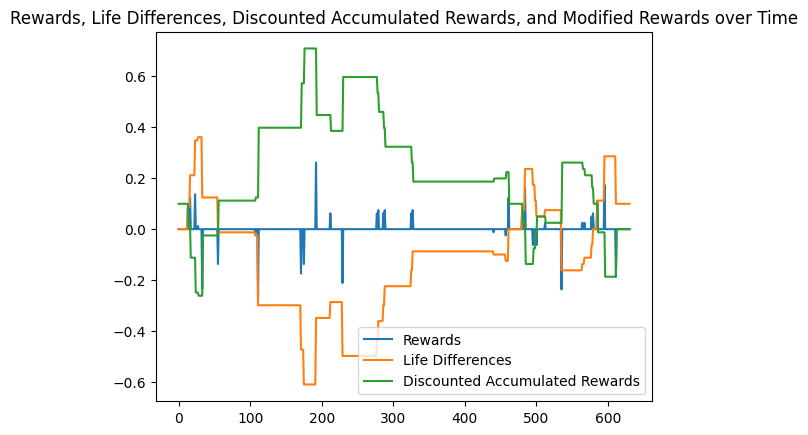

: 

In [ ]:
import numpy as np
_rewards = np.array([float(i) for i in rewards])
print(np.mean(_rewards), np.var(_rewards), len(np.nonzero(_rewards))/len(_rewards))
# the discount factor is 0.99, so the discounted accumulated rewards can be calculated as follows:
discount_factor = 1
# compute the discounted accumulated rewards, computed in a backwards way for return estimation
_discounted_accumulated_rewards = np.zeros_like(_rewards)
running_add = 0
for t in reversed(range(len(_rewards))):
    running_add = _rewards[t] + discount_factor * running_add
    _discounted_accumulated_rewards[t] = running_add
import matplotlib.pyplot as plt
plt.plot(_rewards)
plt.plot(life_differences)
plt.plot(_discounted_accumulated_rewards)

# add legend and title
plt.legend(["Rewards", "Life Differences", "Discounted Accumulated Rewards", "Modified Rewards"])
plt.title("Rewards, Life Differences, Discounted Accumulated Rewards, and Modified Rewards over Time")
plt.show()

In [ ]:
def run(model_checkpoint, env, run_int : int):
#     MAX_VIDEO_LENGTH=1000000000
#     video_folder="."
#     env = VecVideoRecorder(
#     env,
#     video_folder,
#     # Starts recording at the very beginning (global step 0)
#     record_video_trigger=lambda step: step == 0, 
#     video_length=MAX_VIDEO_LENGTH, 
#     name_prefix=f"full-episode-"
# )
    from video_saver import StreamingVideoRender
    saver = StreamingVideoRender(save_path=f"full_video_{model_checkpoint}_{run_int}.mp4", fps=60)
    def unwrap(env):
        return env.envs[0].env.env.env.env.env.env.env.env
    observation = env.reset()
    cumulative_reward = 0
    saver.start(unwrap(env).render().shape)
    while True:
        action, _state = agent.predict(observation, deterministic=False)
        observation, reward, done, info = env.step(action)
        render_env = unwrap(env)
        frame = render_env.render()
        saver.step(frame)
        cumulative_reward += reward
        if (reward != 0):
            print("Cumulative reward =", cumulative_reward)
        if done:
            observation = env.reset()
            break
    saver.stop()
    return cumulative_reward
model_checkpoint = None
for i in range(60):
    reward = run(model_checkpoint, env, i).item()
    with open(f"{model_checkpoint}_{i}.json", 'w') as f:
        json.dump({"reward":reward}, f)

ValueError: Input frame shape must be (H, W, 3) for a color image, but got (128, 128, 1)

In [ ]:
import glob
z = [(i, json.load(open(i))["reward"]) for i in glob.glob("*.json")]
z.sort(key=lambda x:x[-1])
z

[('0_autosave_32300000_21.json', 3.0310566425323486),
 ('0_autosave_32300000_16.json', 3.478266477584839),
 ('0_autosave_32300000_18.json', 3.503103256225586),
 ('0_autosave_32300000_15.json', 5.71428918838501),
 ('0_autosave_32300000_7.json', 5.975159168243408),
 ('0_autosave_32300000_32.json', 6.372685432434082),
 ('0_autosave_32300000_1.json', 7.018640995025635),
 ('0_autosave_32300000_24.json', 7.05590295791626),
 ('0_autosave_32300000_3.json', 7.515536308288574),
 ('0_autosave_32300000_28.json', 7.652174472808838),
 ('0_autosave_32300000_11.json', 7.689452171325684),
 ('0_autosave_32300000_0.json', 7.776401996612549),
 ('0_autosave_32300000_27.json', 7.77640962600708),
 ('0_autosave_32300000_19.json', 7.937901020050049),
 ('0_autosave_32300000_10.json', 8.59628963470459),
 ('0_autosave_32300000_6.json', 8.695652961730957),
 ('0_autosave_32300000_12.json', 8.83230972290039),
 ('0_autosave_32300000_22.json', 8.919269561767578),
 ('0_autosave_32300000_9.json', 9.515547752380371),
 ('

In [ ]:
[i[1] for i in z]

[3.0310566425323486,
 3.478266477584839,
 3.503103256225586,
 5.71428918838501,
 5.975159168243408,
 6.372685432434082,
 7.018640995025635,
 7.05590295791626,
 7.515536308288574,
 7.652174472808838,
 7.689452171325684,
 7.776401996612549,
 7.77640962600708,
 7.937901020050049,
 8.59628963470459,
 8.695652961730957,
 8.83230972290039,
 8.919269561767578,
 9.515547752380371,
 10.409963607788086,
 10.472067832946777,
 10.509332656860352,
 10.534168243408203,
 10.633552551269531,
 10.645971298217773,
 11.540388107299805,
 11.714300155639648,
 11.788830757141113,
 12.099394798278809,
 13.329200744628906,
 13.478273391723633,
 15.32919979095459,
 16.04970359802246]

In [ ]:
import cv2
import numpy as np

# 1. Define the FourCC code for H.264 (avc1)
fourcc = cv2.VideoWriter_fourcc(*'avc1') 

# 2. Set the output file name, frame size, and frames per second (FPS)
output_filename = 'output_video.mp4'
frame_width = 640
frame_height = 480
fps = 30.0

# 3. Initialize the VideoWriter object
out = cv2.VideoWriter(
    output_filename, 
    fourcc, 
    fps, 
    (frame_width, frame_height)
)

# Check if the VideoWriter was successfully initialized
if not out.isOpened():
    print("Error: Could not open the output video file for writing.")
else:
    # 4. Write some frames (e.g., 90 frames for 3 seconds of video)
    print(f"Writing {90} frames to {output_filename}...")
    for i in range(90):
        # Create a blank frame (e.g., black)
        frame = np.zeros((frame_height, frame_width, 3), dtype=np.uint8) 
        
        # Add a colored square or text to show it's working
        cv2.putText(frame, f"Frame: {i}", (50, 240), 
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
        
        # Write the frame
        out.write(frame)

    # 5. Release the VideoWriter object
    out.release()
    print("Video writing complete and resources released.")

Error: Could not open the output video file for writing.


[ERROR:0@259.536] global cap_ffmpeg_impl.hpp:3207 open Could not find encoder for codec_id=27, error: Encoder not found
[ERROR:0@259.536] global cap_ffmpeg_impl.hpp:3285 open VIDEOIO/FFMPEG: Failed to initialize VideoWriter


In [ ]:
from diambra.arena.utils.diambra_data_loader import DiambraDataLoader
dataset_path = "videos/"
data_loader = DiambraDataLoader(dataset_path)

n_loops = data_loader.reset()
from video_saver import StreamingVideoRender

saver = None
terminated = truncated = False
while not (terminated or truncated):
    observation, action, reward, terminated, truncated, info = data_loader.step()
    frame = observation["frame"]
    if saver is None:
        saver = StreamingVideoRender(save_path=f"full_video_{model_checkpoint}.mp4", fps=60)
        saver.start(frame.shape)
    saver.step(frame)
saver.stop()

Renderer is already stopped.


FileNotFoundError: The path 'videos/' does not exist.

In [ ]:
from stable_baselines3.common.evaluation import evaluate_policy
mean_reward, std_reward = evaluate_policy(agent, agent.get_env(), n_eval_episodes=4, deterministic=False, return_episode_rewards=True)

In [ ]:
mean_reward, std_reward

(np.float64(3.8913045), np.float64(1.256268050068237))

In [ ]:
print("Reward: {} (avg) ± {} (std)".format(mean_reward, std_reward))

# Run trained agent
observation = env.reset()
cumulative_reward = 0
while True:

    action, _state = agent.predict(observation, deterministic=False)
    observation, reward, done, info = env.step(action)

    cumulative_reward += reward
    if (reward != 0):
        print("Cumulative reward =", cumulative_reward)

    if done:
        observation = env.reset()
        break

Reward: 3.8913045 (avg) ± 1.256268050068237 (std)


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()